##### Imports

In [2]:
import sys
from pathlib import Path
import scanpy as sc
import matplotlib.pyplot as plt

##### Resolve the directory for the filtered 10X matrix downloaded from GEO, and the analysis directory where results will be written.

In [3]:
_p = Path.cwd().resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, DATA_DIR

##### Import our custom figure plotting dimension code

In [4]:
from src import figure_style as fs

##### Load the Day 10 + Lapatinib matrix into scanpy.

In [5]:
d10_lapa = sc.read_h5ad(DATA_DIR / "data-objects/raw/egfDuod_D10_Lapa_DZ.h5ad")

In [4]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    uns: 'X_name'
    layers: 'counts'

##### Define gene level metadata slots for quality control for mitochondrial and ribosomal DNA, and inspect.

In [12]:
d10_lapa.var["mt"] = d10_lapa.var_names.str.startswith("MT-")

In [13]:
d10_lapa.var["ribo"] = d10_lapa.var_names.str.startswith(("RPS", "RPL"))


In [7]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'mt', 'ribo'
    uns: 'X_name'
    layers: 'counts'

##### Switch the log-normalized and the raw count slots for the purpose of QC

In [14]:
d10_lapa.layers["logcounts"] = d10_lapa.X.copy()
d10_lapa.X = d10_lapa.layers['counts'].copy()

#### Calculate gene QC metrics per cell and per gene

In [15]:
sc.pp.calculate_qc_metrics(d10_lapa, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

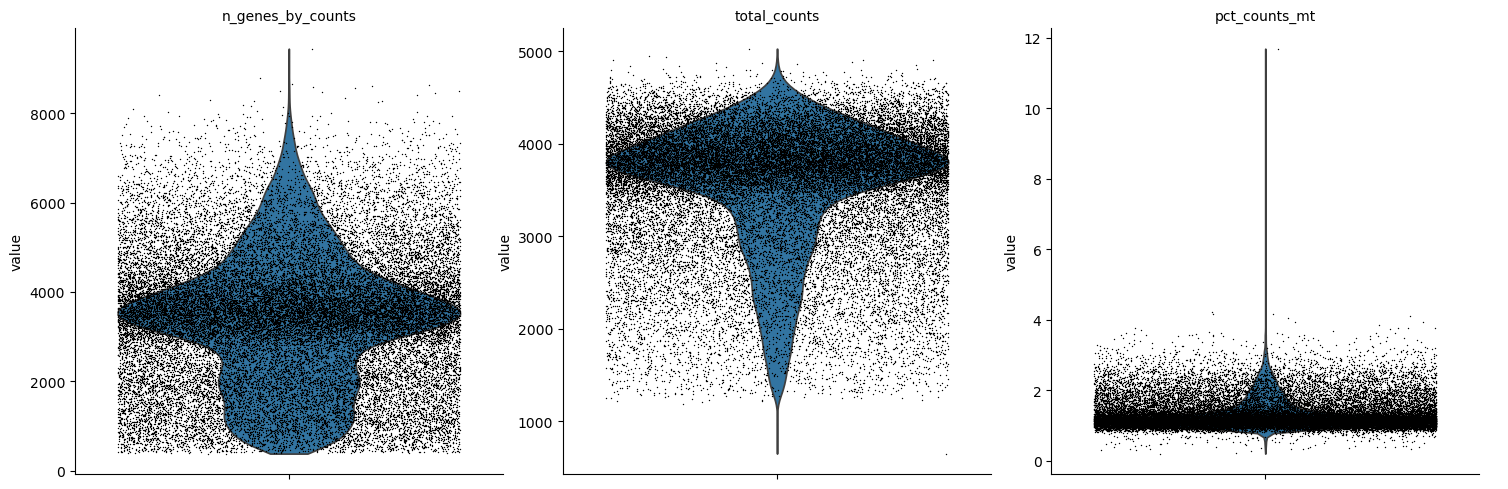

In [10]:
sc.pl.violin(
    d10_lapa,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [10]:
d10_lapa.obs['n_genes_by_counts'].describe()

count    33507.000000
mean      3374.280061
std       1485.247400
min        379.000000
25%       2307.500000
50%       3446.000000
75%       4232.000000
max       9451.000000
Name: n_genes_by_counts, dtype: float64

##### Define our own matplotlib, for Total Counts against Genes Detected

/var/folders/rl/j_1783q13wv5fpfxhl3twdm80000gn/T/ipykernel_34156/3134636393.py:13: UserWarning: Adding colorbar to a different Figure <Figure size 550x500 with 2 Axes> than <Figure size 2064x1556 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(pts, ax=ax, fraction=0.046, pad=0.04)  # own space → won't obscure cells


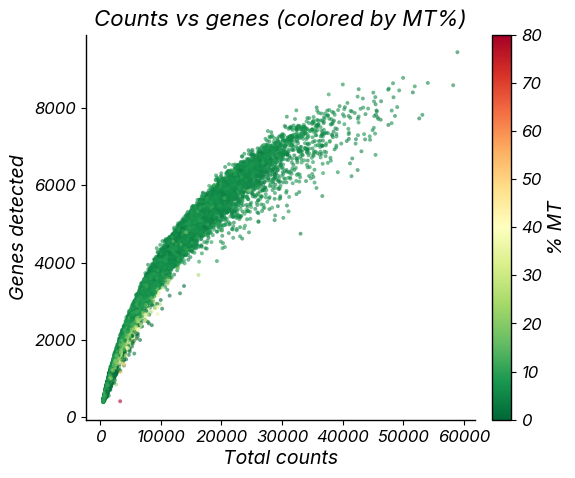

In [ ]:
## Swap out the calling of the axes for our 'make figure function call', in order to create the publication grade plot. 

fig, ax = plt.subplots(figsize=(5.5, 5))
#fig, ax = fs.make_figure(slot="single")

pts = ax.scatter(
    d10_lapa.obs['total_counts'], d10_lapa.obs['n_genes_by_counts'],
    c=d10_lapa.obs['pct_counts_mt'], cmap='RdYlGn_r',
    s=8, alpha=0.6, vmin=0, vmax=80, linewidths=0,
    rasterized=True   
)

cbar = fig.colorbar(pts, ax=ax, fraction=0.046, pad=0.04)  
cbar.set_label('% MT')
cbar.solids.set_alpha(1.0)   

ax.set_xlabel('Total counts')    
ax.set_ylabel('Genes detected')
ax.set_title('Counts vs genes (colored by MT%)')
ax.spines['top'].set_visible(False) # Drop this with the fs.make_figure call
ax.spines['right'].set_visible(False) # Drop this with the fs.make_figure call

In [12]:
d10_lapa.obs[['n_genes_by_counts','total_counts','pct_counts_mt']].describe()


,n_genes_by_counts,total_counts,pct_counts_mt
count,33507.000000,33507.000000,33507.000000
mean,3374.280061,3538.198026,1.325345
std,1485.247400,690.787219,0.428827
min,379.000000,652.269239,0.202120
25%,2307.500000,3237.631449,1.061807
50%,3446.000000,3730.945741,1.184428
75%,4232.000000,3997.354747,1.422449
max,9451.000000,5029.932072,11.687919


##### Plot genes per cell distribution for each donor

In [8]:
d10_lapa.obs['participant'].unique()

['H896', 'H897', 'H329', 'Doublet', 'Negative']
Categories (5, object): ['Doublet', 'H329', 'H896', 'H897', 'Negative']

##### Run the default scrublet pipeline to detect and remove doublets

In [16]:
samples = ["H329", "H896", "H897"]
genes_by_donor = [
   d10_lapa.obs.loc[d10_lapa.obs["participant"] == d, "n_genes_by_counts"].to_numpy()
    for d in samples 
]

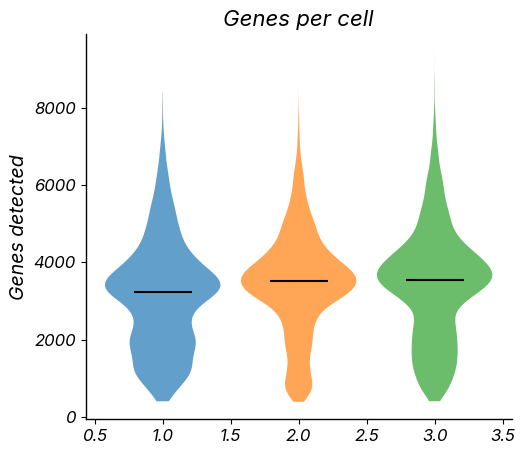

In [30]:
fig, ax = plt.subplots(figsize=(5.5, 5))
#fig, ax = fs.make_figure(slot="single")

parts = ax.violinplot(genes_by_donor, showextrema=False, showmedians=True, widths=0.85)

for body, c in zip(parts["bodies"], ["C0", "C1", "C2"]):
    body.set_facecolor(c); body.set_edgecolor("none"); body.set_alpha(0.7)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.5)


ax.set_ylabel("Genes detected"); ax.set_title("Genes per cell")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

##### Run the built-in scrublet pipeline 

In [13]:
sc.pp.scrublet(d10_lapa)

In [14]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'X_name', 'scrublet'
    layers: 'counts'

In [18]:
d10_lapa.obs[['doublet_score']].describe()


,doublet_score
count,33507.000000
mean,0.078920
std,0.064987
min,0.002036
25%,0.035449
50%,0.058226
75%,0.100491
max,0.643192


In [19]:
d10_lapa.obs[['predicted_doublet']].describe()


,predicted_doublet
count,33507
unique,1
top,False
freq,33507


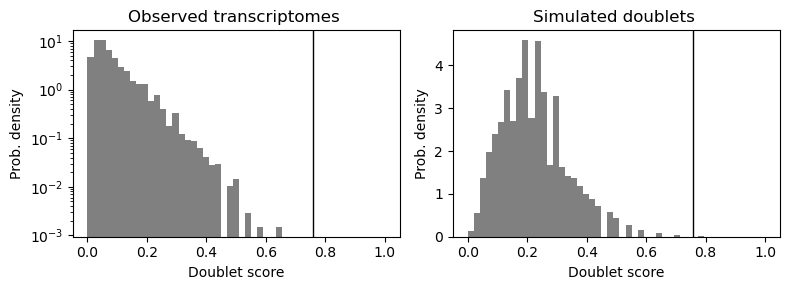

In [23]:
sc.pl.scrublet_score_distribution(d10_lapa)

##### Save the results

In [25]:
intermediate_directory = str(ANALYSIS_DIR / "data-objects/qc")
sc.write(f'{intermediate_directory}/doublet_egfDuod_D10_Lapa_DZ.h5ad', d10_lapa)